# The Great Debate: Are Transformers Effective for Time Series?

**Docker image**: `ml4t-gpu`

This notebook replicates the core finding from Zeng et al. (2023) that simple
linear models can outperform Transformers on long-term time series forecasting.
We implement all three LTSF-Linear variants (Linear, D-Linear, N-Linear)
and a vanilla Transformer to test this claim.

**Learning Objectives**:
- Implement the Linear, D-Linear, and N-Linear baselines from the LTSF-Linear paper
- Build a simple Transformer encoder for time series
- Reproduce the surprising finding that linear models compete with Transformers
- Understand why this result sparked the "great debate" in the field

**Book Reference**: Chapter 13, Section 13.4 (The Great Debate)

**Prerequisites**: ETF price data via the canonical `load_etfs()` loader

In [1]:
"""The Great Debate — test whether simple linear models can outperform Transformers on time series."""

import time
import warnings
from datetime import datetime

import numpy as np
import plotly.graph_objects as go
import polars as pl
import torch
import torch.nn as nn
from ml4t.diagnostic.metrics import pooled_ic

from data import load_etfs
from utils.reproducibility import set_global_seeds

warnings.filterwarnings("ignore")

In [2]:
SEED = 42
LOOKBACK = 96
HORIZON = 24
D_MODEL = 32
N_HEADS = 4
N_LAYERS = 2
EPOCHS = 30
BATCH_SIZE = 32
START_DATE = "2015-01-01"

In [3]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

set_global_seeds(SEED)

Using device: cuda


## Data Preparation

We align several ETF series to a common calendar but run the core
Linear-versus-Transformer comparison on SPY. This is a deliberate
simplification: the Zeng et al. critique is about a single-series LTSF
experiment, and a multi-symbol panel adds confounders (cross-sectional
variance, multi-asset attention) we do not want to entangle with the
main question.

In [4]:
etf_df = load_etfs()

start_dt = datetime.fromisoformat(START_DATE)
SYMBOLS = ["SPY", "QQQ", "IWM", "TLT", "GLD"]

close_wide = (
    etf_df.filter(pl.col("symbol").is_in(SYMBOLS) & (pl.col("timestamp") >= start_dt))
    .pivot(on="symbol", values="close", index="timestamp")
    .drop_nulls()
    .sort("timestamp")
)

feature_cols = [c for c in close_wide.columns if c != "timestamp"]
returns = close_wide.with_columns(
    [pl.col(c).pct_change().alias(c) for c in feature_cols]
).drop_nulls()

# SPY is the primary series for the LTSF-style univariate comparison
series = returns["SPY"].to_numpy().astype(np.float32)

### Sequence builder

Standard sliding-window construction: each input is `lookback` daily returns
and each target is the next `horizon` returns.

In [5]:
def create_sequences(data, lookback, horizon):
    """Sliding lookback → forecast horizon pairs for univariate forecasting."""
    X, y = [], []
    for i in range(len(data) - lookback - horizon + 1):
        X.append(data[i : i + lookback])
        y.append(data[i + lookback : i + lookback + horizon])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

In [6]:
X, y = create_sequences(series, LOOKBACK, HORIZON)

n = len(X)
train_end = int(n * 0.7)
val_end = int(n * 0.85)

X_train, y_train = X[:train_end], y[:train_end]
X_val, y_val = X[train_end:val_end], y[train_end:val_end]
X_test, y_test = X[val_end:], y[val_end:]

print(f"Sequences: {X.shape}, Target: {y.shape}")
print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")

Sequences: (2646, 96), Target: (2646, 24)
Train: 1852, Val: 397, Test: 397


**Note**: We use a fixed 70/15/15 chronological split for clarity. In practice,
walk-forward validation (Section 13.7) is preferred to avoid optimistic estimates
from a single split.

## Model Definitions

### Linear (Plain)
The simplest possible baseline: a single matrix multiplication from
lookback window to forecast horizon. No decomposition, no normalization.

In [7]:
class Linear(nn.Module):
    """Plain linear mapping from lookback to horizon — the simplest baseline."""

    def __init__(self, lookback, horizon):
        super().__init__()
        self.linear = nn.Linear(lookback, horizon)

    def forward(self, x):
        return self.linear(x)

### D-Linear
Decomposes input into trend (moving average) and remainder,
applies separate linear layers to each.

In [8]:
class DLinear(nn.Module):
    """Decomposition-Linear: separate linear for trend and remainder."""

    def __init__(self, lookback, horizon, kernel_size=25):
        super().__init__()
        self.lookback = lookback
        self.horizon = horizon
        self.kernel_size = kernel_size
        # No internal padding — we explicitly edge-pad inputs in `forward`
        # so the moving average mirrors the boundary values instead of
        # injecting zeros, which would bias the trend toward zero near the
        # window edges.
        self.avg_pool = nn.AvgPool1d(kernel_size=kernel_size, stride=1, padding=0)
        self.linear_trend = nn.Linear(lookback, horizon)
        self.linear_remainder = nn.Linear(lookback, horizon)

    def forward(self, x):
        # x: (batch, lookback)
        pad = self.kernel_size // 2
        # Replicate boundary values so the MA at the edges uses real data
        # instead of zero-padded ghost samples.
        x_padded = nn.functional.pad(x.unsqueeze(1), (pad, pad), mode="replicate")
        trend = self.avg_pool(x_padded).squeeze(1)[:, : self.lookback]
        remainder = x - trend
        return self.linear_trend(trend) + self.linear_remainder(remainder)

### N-Linear
Normalizes input by subtracting the last value, applies a linear layer,
then adds back the normalization.

In [9]:
class NLinear(nn.Module):
    """Normalization-Linear: normalize by last value before linear."""

    def __init__(self, lookback, horizon):
        super().__init__()
        self.linear = nn.Linear(lookback, horizon)

    def forward(self, x):
        # x: (batch, lookback)
        last_val = x[:, -1:]  # (batch, 1)
        x_norm = x - last_val
        forecast = self.linear(x_norm)
        return forecast + last_val

### Vanilla Transformer
Standard Transformer encoder with positional encoding for time series.

In [10]:
class SimpleTransformer(nn.Module):
    """Vanilla Transformer encoder for time series forecasting."""

    def __init__(self, lookback, horizon, d_model, n_heads, n_layers, dropout=0.1):
        super().__init__()
        self.input_proj = nn.Linear(1, d_model)
        self.pos_encoding = nn.Parameter(torch.randn(1, lookback, d_model) * 0.02)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=d_model * 4,
            dropout=dropout,
            batch_first=True,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.head = nn.Linear(lookback * d_model, horizon)

    def forward(self, x):
        # x: (batch, lookback)
        x = x.unsqueeze(-1)  # (batch, lookback, 1)
        x = self.input_proj(x)  # (batch, lookback, d_model)
        x = x + self.pos_encoding
        x = self.encoder(x)
        x = x.flatten(1)  # (batch, lookback * d_model)
        return self.head(x)

## Training

In [11]:
def train_model(model, X_train, y_train, X_val, y_val, epochs, batch_size, lr=1e-3):
    """Train with MSE loss + early stopping; returns (best-state model, best val MSE)."""
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    X_tr = torch.FloatTensor(X_train).to(DEVICE)
    y_tr = torch.FloatTensor(y_train).to(DEVICE)
    X_v = torch.FloatTensor(X_val).to(DEVICE)
    y_v = torch.FloatTensor(y_val).to(DEVICE)
    best_val = float("inf")
    best_state = None
    patience_counter = 0
    for epoch in range(epochs):
        model.train()
        indices = torch.randperm(len(X_tr))
        for i in range(0, len(indices), batch_size):
            idx = indices[i : i + batch_size]
            loss = criterion(model(X_tr[idx]), y_tr[idx])
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(X_v), y_v).item()
        if val_loss < best_val:
            best_val = val_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
        if patience_counter >= 5:
            break
    if best_state:
        model.load_state_dict(best_state)
    return model, best_val

## Run Experiments

In [12]:
models = {
    "Linear": Linear(LOOKBACK, HORIZON).to(DEVICE),
    "D-Linear": DLinear(LOOKBACK, HORIZON).to(DEVICE),
    "N-Linear": NLinear(LOOKBACK, HORIZON).to(DEVICE),
    "Transformer": SimpleTransformer(LOOKBACK, HORIZON, D_MODEL, N_HEADS, N_LAYERS).to(DEVICE),
}

results = {}

for name, model in models.items():
    n_params = sum(p.numel() for p in model.parameters())
    print(f"\nTraining {name} ({n_params:,} params)...")

    start_time = time.time()
    model, best_val = train_model(model, X_train, y_train, X_val, y_val, EPOCHS, BATCH_SIZE)
    train_time = time.time() - start_time

    model.eval()
    with torch.no_grad():
        pred = model(torch.FloatTensor(X_test).to(DEVICE)).cpu().numpy()

    mse = np.mean((pred - y_test) ** 2)
    mae = np.mean(np.abs(pred - y_test))
    ic = pooled_ic(pred.mean(axis=1), y_test.mean(axis=1))

    results[name] = {"mse": mse, "mae": mae, "ic": ic, "time": train_time, "params": n_params}
    print(f"  MSE={mse:.6f}, MAE={mae:.6f}, IC={ic:.4f}, Time={train_time:.1f}s")


Training Linear (2,328 params)...


  MSE=0.000134, MAE=0.007425, IC=0.1131, Time=1.2s

Training D-Linear (4,656 params)...


  MSE=0.000135, MAE=0.007466, IC=0.1387, Time=0.7s

Training N-Linear (2,328 params)...


  MSE=0.000136, MAE=0.007443, IC=-0.1773, Time=0.8s

Training Transformer (102,296 params)...


  MSE=0.000249, MAE=0.011410, IC=0.0532, Time=4.3s


## Results Comparison

In [13]:
comparison_data = []
for name, r in results.items():
    comparison_data.append(
        {
            "Model": name,
            "Params": f"{r['params']:,}",
            "MSE": round(r["mse"], 6),
            "MAE": round(r["mae"], 6),
            "IC": round(r["ic"], 4),
            "Time (s)": round(r["time"], 1),
        }
    )

comparison_df = pl.DataFrame(comparison_data)
comparison_df

Model,Params,MSE,MAE,IC,Time (s)
str,str,f64,f64,f64,f64
"""Linear""","""2,328""",0.000134,0.007425,0.1131,1.2
"""D-Linear""","""4,656""",0.000135,0.007466,0.1387,0.7
"""N-Linear""","""2,328""",0.000136,0.007443,-0.1773,0.8
"""Transformer""","""102,296""",0.000249,0.01141,0.0532,4.3


**Interpretation**: Consistent with Zeng et al., the linear baselines achieve
roughly half the MSE of the Transformer (see the `comparison_df` cell above)
with roughly 44× fewer parameters and a fraction of the training time. The
Transformer's additional capacity does not translate to improved accuracy
on this univariate task — supporting the critique that self-attention may
underutilize temporal structure here.

Note that N-Linear's IC is negative, meaning its rank ordering inversely
correlates with actuals despite low MSE. This can happen when a model
produces predictions with small variance concentrated near the mean — MSE
stays low, but cross-sectional ranking fails. D-Linear's decomposition
yields the highest IC among the linear variants.

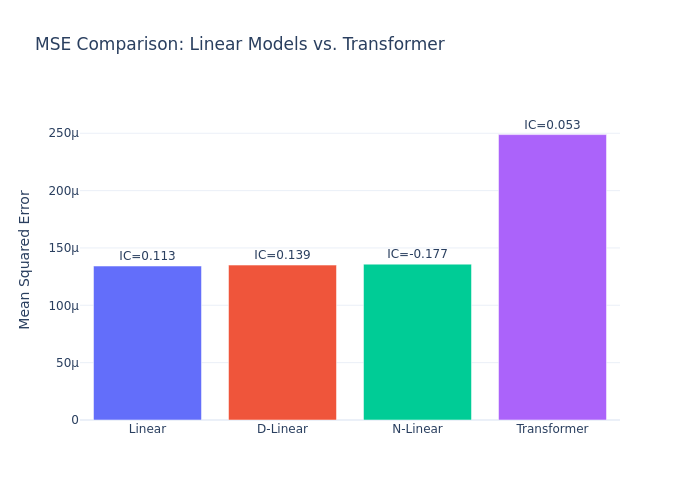

In [14]:
fig = go.Figure()
for name, r in results.items():
    fig.add_trace(
        go.Bar(
            x=[name],
            y=[r["mse"]],
            name=name,
            text=[f"IC={r['ic']:.3f}"],
            textposition="outside",
        )
    )

fig.update_layout(
    title="MSE Comparison: Linear Models vs. Transformer",
    yaxis_title="Mean Squared Error",
    template="plotly_white",
    showlegend=False,
)
fig.show()

## Shuffle Experiment

The most striking diagnostic from Zeng et al.: when input sequences are randomly
shuffled (destroying temporal order), Transformers are largely unaffected while
linear models collapse. This reveals that Transformers rely on pointwise
correlations rather than sequential structure.

In [15]:
# Evaluate all models on original and shuffled test inputs
X_test_t = torch.FloatTensor(X_test).to(DEVICE)

# Shuffle each sample's time steps independently
rng = np.random.default_rng(SEED)
X_shuffled = X_test.copy()
for i in range(len(X_shuffled)):
    rng.shuffle(X_shuffled[i])
X_shuffled_t = torch.FloatTensor(X_shuffled).to(DEVICE)

shuffle_results = []
for name, model in models.items():
    model.eval()
    with torch.no_grad():
        pred_orig = model(X_test_t).cpu().numpy()
        pred_shuf = model(X_shuffled_t).cpu().numpy()

    mse_orig = float(np.mean((pred_orig - y_test) ** 2))
    mse_shuf = float(np.mean((pred_shuf - y_test) ** 2))
    shuffle_results.append(
        {
            "Model": name,
            "MSE (original)": round(mse_orig, 6),
            "MSE (shuffled)": round(mse_shuf, 6),
            "Delta (%)": round(100 * (mse_shuf - mse_orig) / mse_orig, 1),
        }
    )

shuffle_df = pl.DataFrame(shuffle_results)
shuffle_df

Model,MSE (original),MSE (shuffled),Delta (%)
str,f64,f64,f64
"""Linear""",0.000134,0.000129,-3.7
"""D-Linear""",0.000135,0.00013,-3.7
"""N-Linear""",0.000136,0.000131,-3.7
"""Transformer""",0.000249,0.000249,-0.1


**Finding**: On this SPY split, shuffling has minimal impact on any model.
The Transformer's MSE is essentially unchanged and the linear models also
show negligible change. This is a diagnostic on one univariate financial
series — not a proof that daily equity returns are i.i.d., and not a claim
that self-attention generally ignores temporal order; the original Zeng et
al. shuffle gap was demonstrated on weather and electricity data with
strong periodic patterns, structure that our SPY return series mostly
lacks. Read the result as: when the input carries little sequential signal,
preserving sequential order does not help.

## Lookback Sensitivity

Zeng et al. found that Transformer forecasting error *increased* with longer
lookback windows. We test this on our ETF data with three lookback lengths.

In [16]:
lookback_values = [48, 96, 192]
lookback_results = []

for lb in lookback_values:
    X_lb, y_lb = create_sequences(series, lb, HORIZON)
    n_lb = len(X_lb)
    tr_end = int(n_lb * 0.7)
    val_end = int(n_lb * 0.85)

    lb_models = {
        "Linear": Linear(lb, HORIZON).to(DEVICE),
        "D-Linear": DLinear(lb, HORIZON).to(DEVICE),
        "Transformer": SimpleTransformer(lb, HORIZON, D_MODEL, N_HEADS, N_LAYERS).to(DEVICE),
    }

    for name, model in lb_models.items():
        model, _ = train_model(
            model,
            X_lb[:tr_end],
            y_lb[:tr_end],
            X_lb[tr_end:val_end],
            y_lb[tr_end:val_end],
            EPOCHS,
            BATCH_SIZE,
        )
        model.eval()
        with torch.no_grad():
            pred_lb = model(torch.FloatTensor(X_lb[val_end:]).to(DEVICE)).cpu().numpy()
        mse_lb = float(np.mean((pred_lb - y_lb[val_end:]) ** 2))
        lookback_results.append({"Lookback": lb, "Model": name, "MSE": round(mse_lb, 6)})
    print(f"  Lookback={lb}: done")

lookback_df = pl.DataFrame(lookback_results)
lookback_df

  Lookback=48: done


  Lookback=96: done


  Lookback=192: done


Lookback,Model,MSE
i64,str,f64
48,"""Linear""",0.000129
48,"""D-Linear""",0.000129
48,"""Transformer""",0.000254
96,"""Linear""",0.000134
96,"""D-Linear""",0.000135
96,"""Transformer""",0.000338
192,"""Linear""",0.000141
192,"""D-Linear""",0.000143
192,"""Transformer""",0.000321


**Finding**: Linear models show slightly increasing MSE with longer lookbacks,
consistent with extra context adding noise on near-i.i.d. daily returns. The
Transformer shows non-monotonic behavior — MSE rises from lookback 48 to 96 but
drops at 192, likely reflecting training stochasticity on a single split rather
than a systematic pattern. Zeng et al. observed a starker asymmetry on datasets
with strong periodic patterns (weather, electricity), where linear models
benefited from longer lookbacks while Transformers degraded. The muted effect
here reflects the low autocorrelation of daily equity returns.

## sktime Alternative

sktime provides native implementations of both N-Linear and D-Linear from the
LTSF-Linear paper, so you can reproduce this debate in 5 lines.

**Dependency note**: sktime's neural forecasters require `neuralforecast`, which
depends on `ray` — and ray does not yet support Python 3.14
([ray-project/ray#56434](https://github.com/ray-project/ray/issues/56434)).
Once ray adds 3.14 wheels, install via `uv pip install neuralforecast`
and uncomment the demo below.

In [17]:
# import pandas as pd
# from sktime.forecasting.ltsf import LTSFDLinearForecaster, LTSFNLinearForecaster
#
# spy_close = close_wide.select(["timestamp", "SPY"]).to_pandas()
# spy_close = spy_close.set_index("timestamp")["SPY"].dropna()
# split = int(len(spy_close) * 0.8)
# y_train_sk = spy_close.iloc[:split]
# y_test_sk = spy_close.iloc[split : split + HORIZON]
#
# for name, ForecasterCls in [
#     ("N-Linear", LTSFNLinearForecaster),
#     ("D-Linear", LTSFDLinearForecaster),
# ]:
#     fh_sk = list(range(1, HORIZON + 1))
#     forecaster = ForecasterCls(
#         seq_len=LOOKBACK,
#         pred_len=HORIZON,
#         num_epochs=min(EPOCHS, 10),
#     )
#     forecaster.fit(y_train_sk, fh=fh_sk)
#     y_pred_sk = forecaster.predict()
#     mae_sk = float(np.mean(np.abs(y_test_sk.values - y_pred_sk.values)))
#     print(f"sktime {name}: MAE = {mae_sk:.4f}")

When ray supports Python 3.14, the sktime wrappers reproduce the same
LTSF-Linear architectures with a few lines of code.

## Key Takeaways

1. **Linear baselines match or exceed the Transformer on this univariate task**:
   roughly half the MSE with ~44× fewer parameters, consistent with Zeng et al. (2023)
2. **Three variants**: Linear (plain), D-Linear (trend/remainder decomposition),
   N-Linear (last-value normalization) — all with minimal parameters
3. **Shuffle test**: On i.i.d.-like returns, neither architecture relies on temporal
   order — the original paper's shuffle effect requires strong periodic structure
4. **Lookback sensitivity**: Linear models degrade slightly with longer context on
   low-autocorrelation data; the Zeng et al. asymmetry is most pronounced on periodic series
5. This result motivated better Transformer designs (PatchTST, iTransformer)
   that directly address these failure modes
6. **sktime provides N-Linear/D-Linear natively** — the debate is easy to reproduce

**Caveat**: These results are on univariate SPY data. Transformers may perform
better in multivariate settings with rich covariates where cross-series attention
extracts meaningful relationships (Section 13.5 explores TFT for this case).

**Next**: See `04_transformers` for modern PatchTST and iTransformer architectures.